# Enrichment of the DRVI dimensions - non-immune compartment

First downstream analysis of the DRVI run of 03_2 (`drvi_nonimm_64`, 64 latent dimensions
trained on the 176,610 non-immune cells and their 2,000 compartment-specific HVGs).

03_2 stopped at *which* genes each latent dimension moves - the interpretability scores. This
notebook asks what those gene lists **mean**: each dimension is turned into a ranked gene list,
its top `N_TOP_GENES` genes are sent to Enrichr through `gseapy`, and the significantly enriched
terms are drawn as one barplot per dimension.

**Directions.** A DRVI dimension is read separately in its two directions: `DR 12+` is the set of
genes that go *up* when the dimension increases, `DR 12-` the ones that go up when it decreases.
The two are different biological programs and are enriched separately, so the 64 dimensions give
at most 128 gene lists - minus the directions DRVI let vanish, which are dropped.

**No model is loaded here.** The interpretability scores were computed in 03_2 and written into
`embed_drvi_nonimm_64.h5ad` (`.varm['OOD_combined_positive' / '_negative']`), so this notebook
only needs that file plus the gene names of the DRVI input. The cell below rebuilds exactly what
`model.get_interpretability_scores(embed, adata)` returns, without a GPU and without `scvi-tools`.

`N_TOP_GENES` is the only parameter to edit: the figure folder
(`figures/03_3_enrichment_<N_TOP_GENES>/`) and the results table both follow from it, so a re-run
at another depth never overwrites this one.

## Libraries

In [1]:
import os
import time
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import gseapy as gp

import warnings
warnings.filterwarnings("ignore")

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Scanpy setting: clean white background and high resolution figures
sc.settings.set_figure_params(dpi=300, facecolor="white")
# Set the level of verbosity of scanpy to get more detailed info
sc.settings.verbosity = 3

# Tell Jupyter to show all outputs and not only the last one
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

print("gseapy version:", gp.__version__)

gseapy version: 1.3.0


## Configuration

`N_TOP_GENES` is the depth of the gene list handed to Enrichr, and the only thing to edit when
re-running: 200 is the default, deep enough for a program-level read (Hallmark / Reactome terms
carry 50-200 genes) while still being the top 10% of the 2,000 HVGs. Shallower (50) gives the
few terms a dimension is *most* about; deeper (500) starts enriching the compartment itself
rather than the dimension.

The run id is the one of 03_2 and points at that run's model outputs; it is kept in every file
name, so figures from a re-run at another latent size stay distinguishable.

In [2]:
N_TOP_GENES = 200     # genes per dimension sent to Enrichr (try 50 / 500 to compare)
N_LATENT = 64         # the 03_2 run this reads, see drvi_nonimm.ipynb
OVERWRITE = False     # False reuses the enrichment table already on disk

SCORE_KEY = "OOD_combined"   # the interpretability scores of 03_2 (see the section below)
FDR = 0.05                   # Benjamini-Hochberg cutoff, on Enrichr's own correction

RUN_ID = f"drvi_nonimm_{N_LATENT}"

PROJECT_DIR = Path("/home/albertoc/Desktop/QCB-Master-Thesis")
DATA_DIR = Path(os.environ.get("DATA_DIR", PROJECT_DIR / "datasets"))
PHASE_DIR = PROJECT_DIR / "03_drvi_non_immune"
NONIMM_DIR = DATA_DIR / "03_nonimm"

# Inputs, both written by 03_2 / 03_1 and both read-only here.
LATENT_H5AD = NONIMM_DIR / f"embed_{RUN_ID}.h5ad"          # latent space + interpretability scores
INPUT_H5AD = NONIMM_DIR / "shiao_nonimm_hvg_2k.h5ad"       # only its var_names are needed

# Outputs: the gene lists and the enrichment table, next to the objects they come from
# (the figures go to the repo, see the next cell).
TOP_GENES_TSV = NONIMM_DIR / f"top{N_TOP_GENES}_genes_{RUN_ID}.tsv"
ENRICHR_TSV = NONIMM_DIR / f"enrichr_top{N_TOP_GENES}_{RUN_ID}.tsv"

print(f"run id      {RUN_ID}")
print(f"embedding   {LATENT_H5AD}")
print(f"top genes   {TOP_GENES_TSV}")
print(f"enrichment  {ENRICHR_TSV}")

run id      drvi_nonimm_64
embedding   /home/albertoc/Desktop/QCB-Master-Thesis/datasets/03_nonimm/embed_drvi_nonimm_64.h5ad
top genes   /home/albertoc/Desktop/QCB-Master-Thesis/datasets/03_nonimm/top200_genes_drvi_nonimm_64.tsv
enrichment  /home/albertoc/Desktop/QCB-Master-Thesis/datasets/03_nonimm/enrichr_top200_drvi_nonimm_64.tsv


### Figures

One folder per depth, `03_drvi_non_immune/figures/03_3_enrichment_<N_TOP_GENES>/`, next to the
`03_1_*` and `03_2_*` folders of the previous steps. The run id stays in every file name, as in
03_2, so a figure keeps saying which DRVI run it came from once it is pulled out of its folder.

In [3]:
FIG_DIR = PHASE_DIR / "figures" / f"03_3_enrichment_{N_TOP_GENES}"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sc.settings.figdir = FIG_DIR


def savefig(name, fig=None, dpi=300):
    """Save a matplotlib figure (the current one by default) into FIG_DIR.

    Same helper as 03_2: the run id is appended to the name.
    """
    fig = plt.gcf() if fig is None else fig
    path = FIG_DIR / f"{name}_{RUN_ID}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"[fig] {path}")
    return path


def dim_slug(dim):
    """Turn a dimension title into a file name: 'DR 7+' -> 'DR_07_pos'.

    Zero-padded so the folder lists in dimension order, and the sign spelled out so
    nothing in the name depends on a character a shell might eat.
    """
    number, sign = dim[3:-1], dim[-1]
    return f"DR_{int(number):02d}_{'pos' if sign == '+' else 'neg'}"


print(f"figures     {FIG_DIR}")

figures     /home/albertoc/Desktop/QCB-Master-Thesis/03_drvi_interpretation/figures/03_3_enrichment_200


## Load the DRVI run

Only the embedding is read: it carries the latent dimensions as observations of `.var` (with
their stats and the `vanished` flags) and the per-gene interpretability scores in `.varm`. The
2,000-gene DRVI input is read for its `var_names` alone, which name the columns of those score
matrices.

In [ ]:
embed = sc.read_h5ad(LATENT_H5AD)
embed

adata = sc.read_h5ad(INPUT_H5AD, backed="r")
gene_names = adata.var_names.copy()
adata.file.close()

assert embed.varm[f"{SCORE_KEY}_positive"].shape[1] == len(gene_names), \
    "the embedding and the DRVI input disagree on the gene axis"

n_vanished = int(embed.var["vanished"].sum())
print(f"{embed.n_obs:,} cells x {embed.n_vars} latent dimensions "
      f"({n_vanished} vanished, {embed.n_vars - n_vanished} used)")
print(f"{len(gene_names):,} genes: {list(gene_names[:8])} ...")

AnnData object with n_obs × n_vars = 174487 × 64
    obs: 'sample', 'batch', 'cohort', 'treatment', 'fraction', 'dataset_origin', 'response', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet', 'is_doublet_shiao', 'high_umi_doublet', 'cell_type', 'celltypist_predicted', 'size_factors', 'S_score', 'G2M_score', 'phase', '_scvi_batch', '_scvi_labels'
    var: 'original_dim_id', 'reconstruction_effect', 'order', 'max_value', 'mean', 'min', 'max', 'std', 'std_abs', 'title', 'vanished', 'vanished_positive_direction', 'vanished_negative_direction'
    uns: 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'IND_exp_weighted_mean_negative', 'IND_exp_weighted_mean_positive', 'IND_linear_weighted_mean_negative', 'IND_linear_weighted_mean_positive', 'IND_max_negative', 'IND_max_positive

174,487 cells x 64 latent dimensions (12 vanished, 52 used)
2,000 genes: ['HES4', 'ISG15', 'TNFRSF4', 'MXRA8', 'VWA1', 'MMP23B', 'GABRD', 'SMIM1'] ...


## Interpretability scores

03_2 stored two score matrices per approach, one per direction of each dimension. The helper
below assembles them into the genes x directions table, exactly as
`model.get_interpretability_scores(embed, adata)` does - concatenating the positive and negative
blocks, labelling them `DR n+` / `DR n-`, dropping the directions DRVI let vanish and sorting by
dimension order. Reimplementing those few lines is what lets this notebook skip loading the model
(and with it `scvi-tools`, torch and the GPU); it was checked to return the same table, value by
value.

`OOD_combined` is the default and the right score for this analysis: the out-of-distribution
scores come from the decoder reconstructions and favour the genes *specific* to a dimension,
which is what makes a term list about that dimension rather than about the compartment. The
alternative, `IND_linear_weighted_mean`, averages each factor's effect over all cells and keeps a
shared gene high in every dimension it belongs to: broader, and it would push the same generic
terms into every barplot. Switch `SCORE_KEY` in the configuration cell to compare.

In [5]:
def interpretability_scores(embed, gene_names, key="OOD_combined", hide_vanished=True):
    """Genes x dimension-directions scores from `embed.varm`, as DRVI's own accessor returns."""
    effect = np.concatenate([embed.varm[f"{key}_positive"], embed.varm[f"{key}_negative"]])

    info = (
        pd.concat([embed.var.assign(direction="+"), embed.var.assign(direction="-")])
        .assign(title=lambda df: df["title"] + df["direction"])
        .reset_index(drop=True)
    )
    # A direction is dropped only if DRVI marked *that* direction vanished: a dimension can
    # carry a real program on one side and nothing on the other.
    info["keep"] = ~np.where(
        info["direction"] == "+",
        info["vanished_positive_direction"],
        info["vanished_negative_direction"],
    ) if hide_vanished else True

    return (
        pd.DataFrame(effect, columns=gene_names, index=info["title"])
        .loc[info.query("keep == True").sort_values(["order", "direction"])["title"]]
        .T
    )


scores_df = interpretability_scores(embed, gene_names, key=SCORE_KEY)

print(f"{scores_df.shape[0]:,} genes x {scores_df.shape[1]} dimension-directions "
      f"(out of {2 * embed.n_vars} possible, the rest vanished)")
scores_df.iloc[:8, :8]

2,000 genes x 104 dimension-directions (out of 128 possible, the rest vanished)


title,DR 1+,DR 1-,DR 2+,DR 2-,DR 3+,DR 3-,DR 4+,DR 4-
HES4,3.982024e-10,0.753200,0.005909,3.978897e-10,4.988863e-10,0.000946,0.115995,1.719371e-10
ISG15,4.321619e-06,0.015496,0.010725,1.419409e-08,4.125073e-08,0.111667,0.004167,2.590150e-08
TNFRSF4,4.613753e-09,0.000011,0.175327,0.000000e+00,0.000000e+00,0.070689,0.000126,0.000000e+00
MXRA8,1.845990e-11,0.059799,0.126266,0.000000e+00,1.955414e-11,0.000012,0.031889,5.556444e-12
VWA1,1.458034e-11,0.299601,0.002485,7.531753e-12,1.043077e-11,0.728616,0.089191,2.543743e-12
MMP23B,7.405987e-10,0.000064,0.082317,0.000000e+00,6.821210e-13,0.000026,0.000281,1.492140e-12
GABRD,1.257661e-12,0.000016,0.002954,1.193712e-12,2.774435e-09,0.000020,0.004282,7.389644e-13
SMIM1,4.036593e-10,0.069618,0.011380,3.688569e-10,2.680466e-09,0.006849,0.105799,1.583658e-10


## Top genes per dimension

The ranked list each dimension contributes: its `N_TOP_GENES` highest-scoring genes, in score
order. Saved as a table so the lists behind the barplots can be read (and quoted) without
re-running anything.

In [6]:
top_genes = {
    dim: scores_df[dim].sort_values(ascending=False).head(N_TOP_GENES).index.tolist()
    for dim in scores_df.columns
}

# One column per dimension, one row per rank.
top_genes_df = pd.DataFrame(top_genes, index=pd.RangeIndex(1, N_TOP_GENES + 1, name="rank"))
top_genes_df.to_csv(TOP_GENES_TSV, sep="\t")
print(f"[write] {TOP_GENES_TSV}")

# The first dimensions are the ones DRVI reconstructs the most, i.e. where to start reading.
top_genes_df.iloc[:15, :8]

[write] /home/albertoc/Desktop/QCB-Master-Thesis/datasets/03_nonimm/top200_genes_drvi_nonimm_64.tsv


,DR 1+,DR 1-,DR 2+,DR 2-,DR 3+,DR 3-,DR 4+,DR 4-
rank,,,,,,,,
1,VIM,GDF15,TAC1,MTRNR2L12,LGALS3BP,SELE,DCD,HSPA1A
2,IFI27,CLCA2,ECEL1,S100A1,TENT5A,ACKR1,PCSK1N,HSPA1B
3,SPHK1,DEFB1,TNN,S100B,FABP7,CCL23,CD24,MTRNR2L12
4,ISG15,SPTSSB,DLK1,PCSK1N,TUBB2B,CSF2RB,SCD,SCRG1
5,S100B,LY6D,PENK,PNP,S100A1,SELP,MAL2,AP1S2
6,RGS2,CALML3,DCX,FABP7,SGCE,ZNF385D,KLF5,IFI6
7,NDRG1,PTHLH,IGF1,HACD1,HEY1,ADM5,AARD,S100A1
8,FABP7,KRT19,GPR174,AIF1L,CD44,CDKN3,TM7SF2,MT2A
9,S100A1,SLC7A2,STRA6,TTYH1,ITM2C,TSPAN7,DSC2,FABP7


In [7]:
# The head of every list, as a quick sanity read before the enrichment: cell-type markers on the
# identity dimensions, programs (ECM, interferon, cycle) on the rest.
for dim, genes in top_genes.items():
    print(f"{dim:>8}: {', '.join(genes[:15])}")

   DR 1+: VIM, IFI27, SPHK1, ISG15, S100B, RGS2, NDRG1, FABP7, S100A1, SCRG1, EDNRB, IFI44L, LOXL2, PCSK1N, LBH
   DR 1-: GDF15, CLCA2, DEFB1, SPTSSB, LY6D, CALML3, PTHLH, KRT19, SLC7A2, TFAP2B, SDC1, GALNT6, DCDC2, RRAD, GATA3
   DR 2+: TAC1, ECEL1, TNN, DLK1, PENK, DCX, IGF1, GPR174, STRA6, AL513283.1, ITM2A, NPPC, CRABP1, ALX4, SST
   DR 2-: MTRNR2L12, S100A1, S100B, PCSK1N, PNP, FABP7, HACD1, AIF1L, TTYH1, ATP6V0E2, SCRG1, SPHK1, BAMBI, MT3, TUBB2B
   DR 3+: LGALS3BP, TENT5A, FABP7, TUBB2B, S100A1, SGCE, HEY1, CD44, ITM2C, CKB, S100B, BAMBI, PCSK1N, IGFBP5, SCRG1
   DR 3-: SELE, ACKR1, CCL23, CSF2RB, SELP, ZNF385D, ADM5, CDKN3, TSPAN7, RBP5, IL3RA, PRCP, TACR1, G0S2, SPARCL1
   DR 4+: DCD, PCSK1N, CD24, SCD, MAL2, KLF5, AARD, TM7SF2, DSC2, S100A1, SFRP1, AQP5, DSP, SPINT2, ATP6V0E2
   DR 4-: HSPA1A, HSPA1B, MTRNR2L12, SCRG1, AP1S2, IFI6, S100A1, MT2A, FABP7, S100B, AL138963.3, IGFBP5, IFITM1, MALAT1, HACD1
   DR 5+: SLPI, SERHL2, MUCL1, APOD, HPGD, AC093001.1, UGT2B28, LRRC26, AZGP

## Gene set libraries

Four Enrichr libraries, chosen for a compartment made of fibroblasts, luminal and basal
epithelium, endothelium and perivascular cells in a treated tumour:

- **MSigDB_Hallmark_2020** - 50 deliberately non-redundant programs.
- **Reactome_Pathways_2024** - curated pathways, the level below Hallmark. 
- **GO_Biological_Process_2025** - the widest coverage of the four, and the only one that
  reliably annotates the smaller populations (vascular, lymphatic, perivascular). 
- **KEGG_2021_Human** - canonical signalling, kept because it is the most quoted of the four and
  gives a familiar name to what the others describe.

In [9]:
# One colour per library, so the barplots stay readable when several of them hit the same term.
GENE_SETS = {
    "MSigDB_Hallmark_2020": "#4C72B0",
    "Reactome_Pathways_2024": "#55A868",
    "GO_Biological_Process_2025": "#DD8452",
    "KEGG_2021_Human": "#C44E52",
}

TOP_TERMS_PER_LIBRARY = 6   # terms plotted per library, ranked by adjusted p-value

list(GENE_SETS)

['MSigDB_Hallmark_2020',
 'Reactome_Pathways_2024',
 'GO_Biological_Process_2025',
 'KEGG_2021_Human']

### Background

The universe is the **2,000 HVGs**, not the whole genome. Enrichr's web endpoint always tests
against all human genes, which here would be wrong in one direction: the 200 genes are drawn from
a list already selected for variability in this compartment, so any term rich in variable genes -
ECM, cycle, interferon - looks enriched before any dimension is considered. Passing the HVG list
as `background` makes `gseapy` run the hypergeometric test locally against that universe instead,
which is the comparison the question actually asks: *among the genes DRVI could have picked, is
this term over-represented in the ones it did pick?*

`HVG_BACKGROUND = False` falls back to the web endpoint (all human genes) if the results are ever
to be compared with a run made that way; the p-values are then optimistic, and the term tables
gain an `Overlap` column the local mode does not report.

In [10]:
HVG_BACKGROUND = True

background = list(gene_names) if HVG_BACKGROUND else None
print(f"background: {len(background):,} HVGs" if background else "background: Enrichr default (all human genes)")

background: 2,000 HVGs


## Enrichment

One Enrichr query per dimension-direction against the four libraries, concatenated into a single
table with the dimension as a column. Written to disk, and re-read instead of re-queried unless
`OVERWRITE` asks otherwise: the barplots below can then be re-drawn as often as needed without
touching the network.

In [11]:
if OVERWRITE or not ENRICHR_TSV.exists():
    results, failed = [], []

    for i, (dim, genes) in enumerate(top_genes.items(), start=1):
        try:
            enr = gp.enrichr(
                gene_list=genes,
                gene_sets=list(GENE_SETS),
                organism="human",
                background=background,
                outdir=None,
            )
        except Exception as exc:                    # a library timing out, mostly
            print(f"  [{i:>3}/{len(top_genes)}] {dim:>8}  FAILED: {exc}")
            failed.append(dim)
            continue

        df = enr.results.copy()
        df.insert(0, "dimension", dim)
        results.append(df)

        n_sig = int((df["Adjusted P-value"] < FDR).sum())
        print(f"  [{i:>3}/{len(top_genes)}] {dim:>8}  {n_sig:>4} terms at FDR < {FDR}")

    enrich_df = pd.concat(results, ignore_index=True)
    enrich_df.to_csv(ENRICHR_TSV, sep="\t", index=False)
    print(f"\n[write] {ENRICHR_TSV}")
    if failed:
        print(f"[warn] no result for: {', '.join(failed)}")
else:
    enrich_df = pd.read_csv(ENRICHR_TSV, sep="\t")
    print(f"[read] {ENRICHR_TSV} (OVERWRITE=False)")

enrich_df["-log10_adj_p"] = -np.log10(enrich_df["Adjusted P-value"].clip(lower=1e-300))
print(f"{len(enrich_df):,} tested terms, "
      f"{int((enrich_df['Adjusted P-value'] < FDR).sum()):,} significant at FDR < {FDR}")
enrich_df.head()

[read] /home/albertoc/Desktop/QCB-Master-Thesis/datasets/03_nonimm/enrichr_top200_drvi_nonimm_64.tsv (OVERWRITE=False)
253,391 tested terms, 5,261 significant at FDR < 0.05


,dimension,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes,-log10_adj_p
0,DR 1+,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.000002,0.000074,0,0,3.118343,41.407627,SPARC;SERPINE2;HTRA1;FSTL1;MYLK;LOXL2;GJA1;EFE...,4.133409
1,DR 1+,MSigDB_Hallmark_2020,Interferon Alpha Response,0.000012,0.000266,0,0,6.319149,71.412041,BST2;IFITM1;PLSCR1;IFITM2;RSAD2;IFI27;MX1;EPST...,3.575478
2,DR 1+,MSigDB_Hallmark_2020,Interferon Gamma Response,0.000042,0.000603,0,0,3.460127,34.866431,IFITM2;VCAM1;RSAD2;MX1;ISG15;IFIT1;PTGS2;IFI44...,3.219879
3,DR 1+,MSigDB_Hallmark_2020,KRAS Signaling Up,0.004435,0.047678,0,0,2.358696,12.779840,SPON1;GYPC;TMEM176B;IGFBP3;TMEM176A;G0S2;LY96;...,1.321678
4,DR 1+,MSigDB_Hallmark_2020,Coagulation,0.008761,0.075346,0,0,2.489362,11.793152,MMP14;SPARC;ANXA1;GSN;PLAU;S100A1;HTRA1;FN1;SE...,1.122937


In [12]:
# How many dimensions the enrichment actually says something about, and which ones it does not:
# a direction with no significant term is a real result, not a failure - it is DRVI having found
# an axis that no annotated gene set describes.
n_sig = (
    enrich_df[enrich_df["Adjusted P-value"] < FDR]
    .groupby("dimension").size()
    .reindex(top_genes.keys(), fill_value=0)
    .rename("n_significant_terms")
)

print(f"{int((n_sig > 0).sum())} / {len(n_sig)} dimension-directions with at least one term "
      f"at FDR < {FDR}")
print("no enriched term:", ", ".join(n_sig[n_sig == 0].index) or "none")
n_sig.sort_values(ascending=False).head(15)

102 / 104 dimension-directions with at least one term at FDR < 0.05
no enriched term: DR 20+, DR 41+


dimension
DR 22-    227
DR 16-    194
DR 20-    182
DR 36-    177
DR 47+    169
DR 44-    145
DR 41-    117
DR 26+    115
DR 7-     109
DR 40+    109
DR 48+    107
DR 46+    105
DR 6-     100
DR 13-     90
DR 11-     88
Name: n_significant_terms, dtype: int64

## Barplots

One figure per dimension-direction, `DR_<nn>_<pos|neg>_enrichr_barplot_<run_id>.png`: the terms
below the FDR cutoff, up to `TOP_TERMS_PER_LIBRARY` per library, bars coloured by library and
scaled by -log10 of the adjusted p-value. Dimensions with nothing significant are skipped and
listed at the end.

Long term names are truncated to keep the y-axis readable; the full names are in `enrich_df` and
in the saved table.

In [13]:
MAX_TERM_CHARS = 60

def shorten(term):
    """Truncate a term name for the y-axis; the full one stays in the results table."""
    return term if len(term) <= MAX_TERM_CHARS else term[:MAX_TERM_CHARS - 1].rstrip() + "…"


plotted, skipped = [], []

for dim in top_genes:
    df = enrich_df.query("dimension == @dim").copy()
    if df.empty or (df["Adjusted P-value"] >= FDR).all():
        skipped.append(dim)
        continue

    df["Term"] = df["Term"].map(shorten)

    # gp.barplot draws and saves in one call (ofname), which avoids the figure it creates
    # internally ending up saved by a plt.savefig aimed at another one.
    gp.barplot(
        df,
        column="Adjusted P-value",
        group="Gene_set",
        top_term=TOP_TERMS_PER_LIBRARY,
        cutoff=FDR,
        color=GENE_SETS,
        title=f"{dim}   (top {N_TOP_GENES} genes)",
        figsize=(7, 9),
        ofname=str(FIG_DIR / f"{dim_slug(dim)}_enrichr_barplot_{RUN_ID}.png"),
    )
    plotted.append(dim)

print(f"[fig] {len(plotted)} barplots in {FIG_DIR}")
if skipped:
    print(f"skipped (no term at FDR < {FDR}): {', '.join(skipped)}")

[fig] 102 barplots in /home/albertoc/Desktop/QCB-Master-Thesis/03_drvi_interpretation/figures/03_3_enrichment_200
skipped (no term at FDR < 0.05): DR 20+, DR 41+


<Axes: title={'center': 'DR 1+ - top 200 genes'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

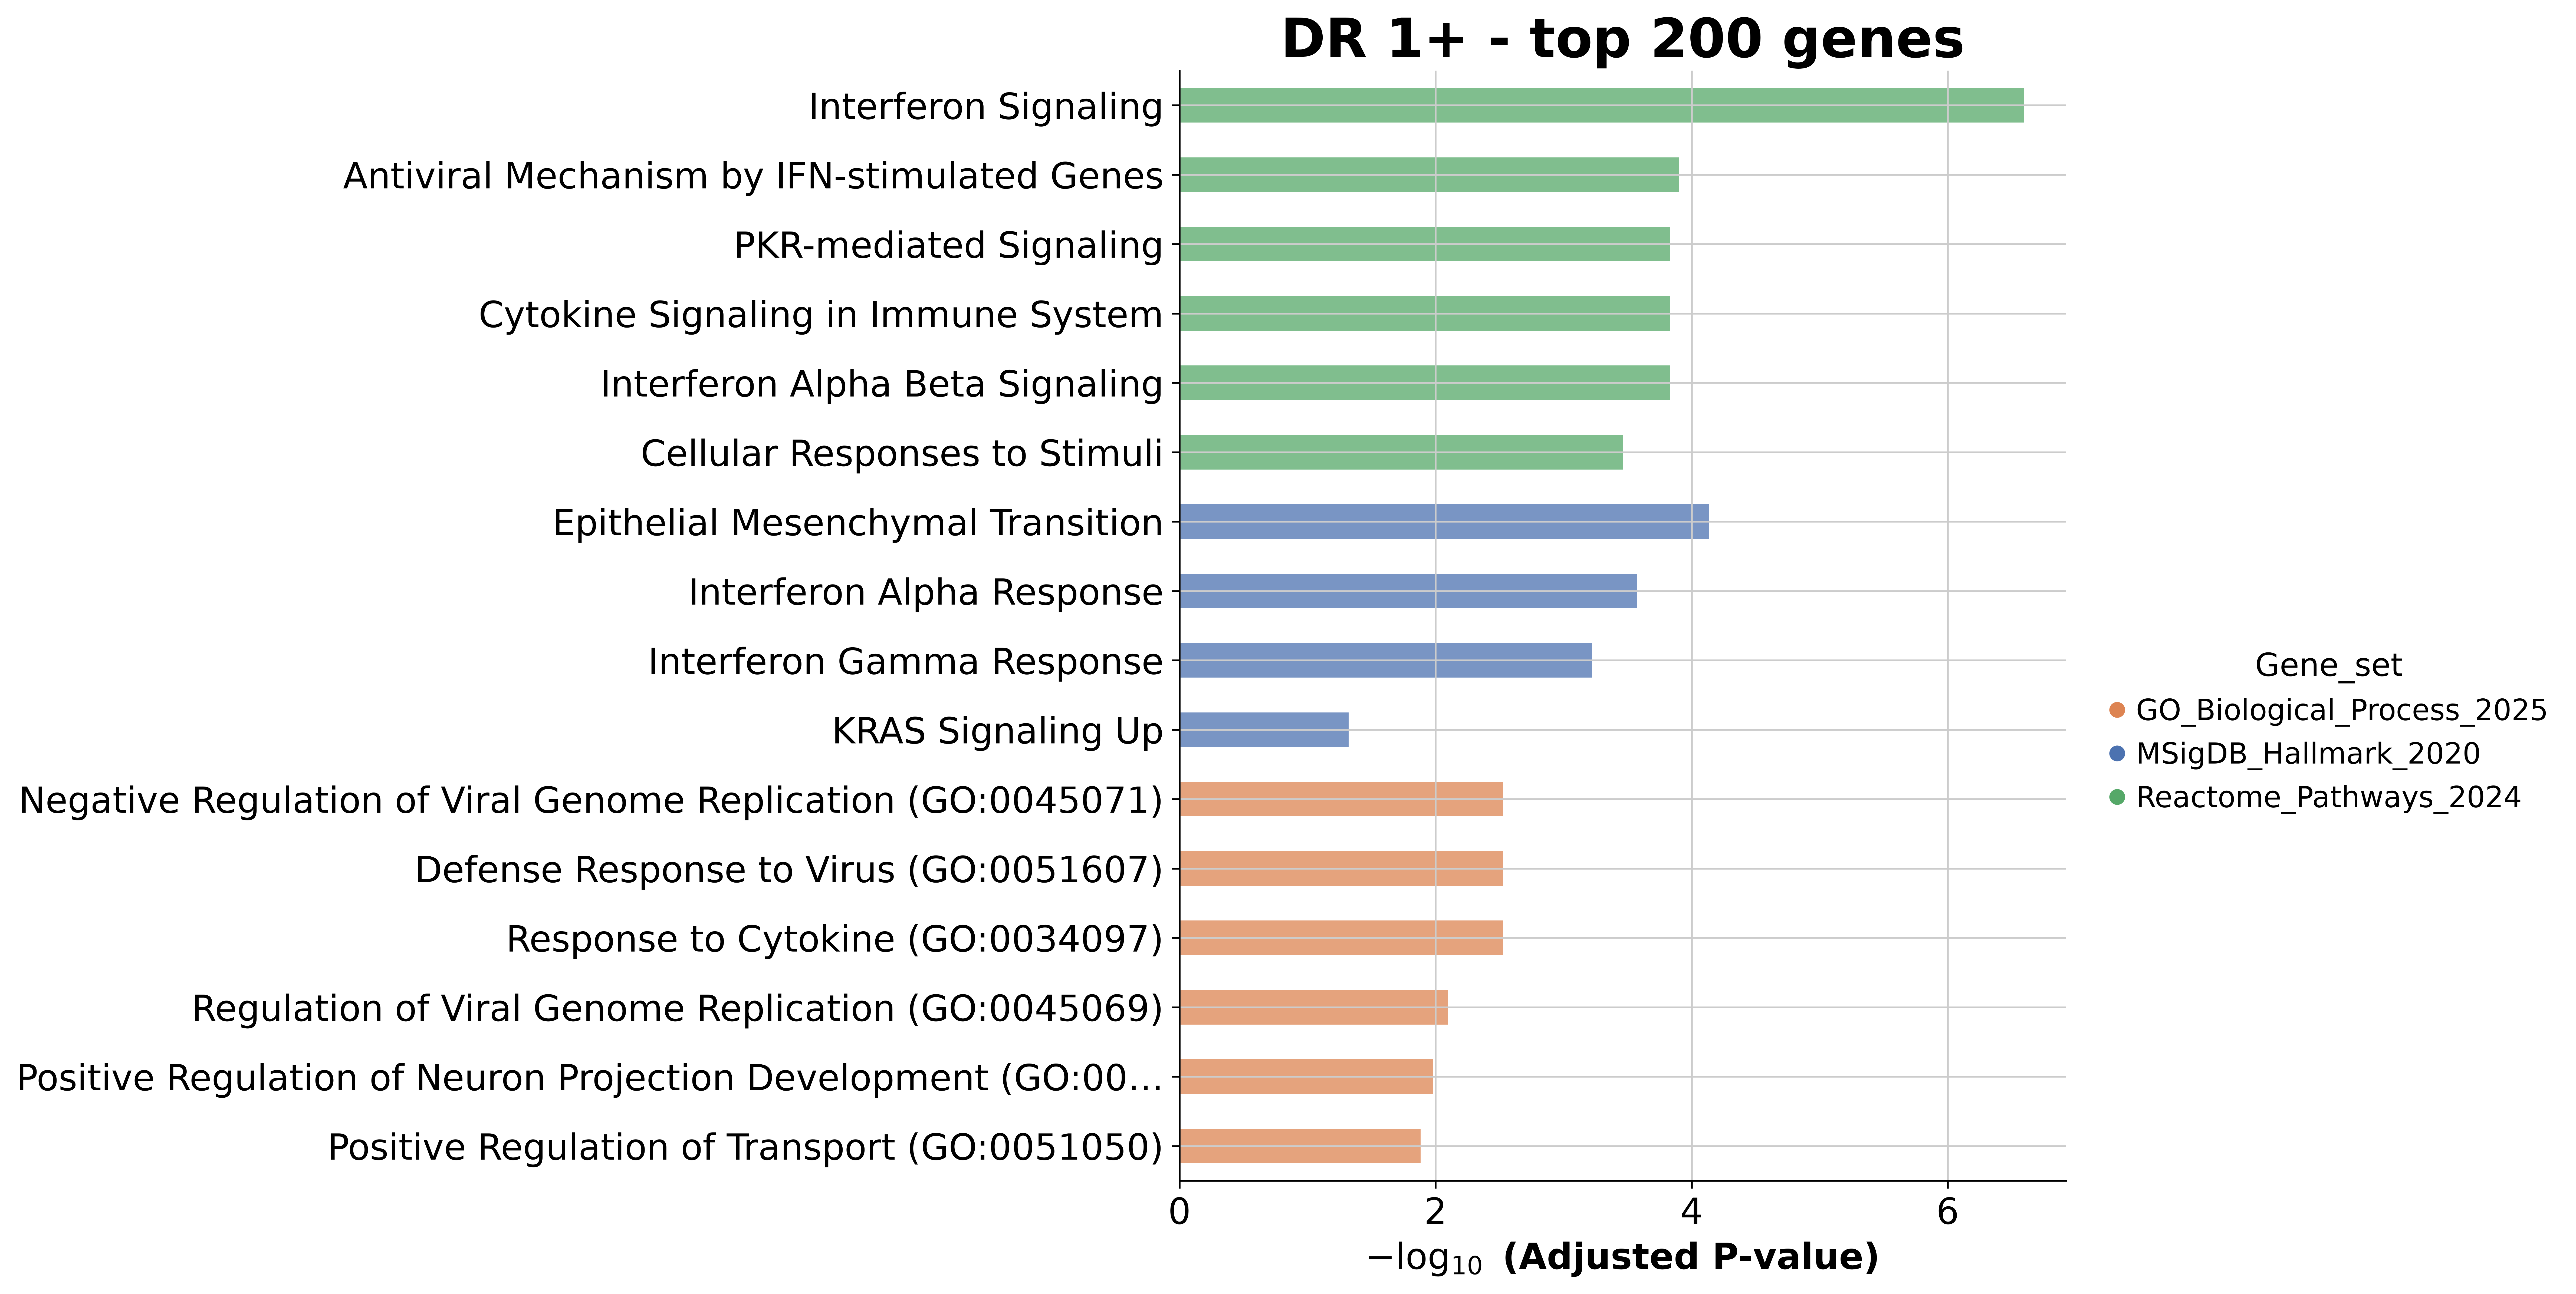

In [14]:
# The same plot for one dimension, shown inline: the first one, i.e. the direction of the
# dimension DRVI reconstructs the most.
dim = plotted[0]
df = enrich_df.query("dimension == @dim").copy()
df["Term"] = df["Term"].map(shorten)

gp.barplot(
    df,
    column="Adjusted P-value",
    group="Gene_set",
    top_term=TOP_TERMS_PER_LIBRARY,
    cutoff=FDR,
    color=GENE_SETS,
    title=f"{dim} - top {N_TOP_GENES} genes",
    figsize=(7, 9),
)
plt.show()